# Wrapped-layout comparison

Normalized-stress TorusMDS versus `wrap_typescript`, `wrap_python_newdist`, and `wrap_python` on SBM, GRG, and SuiteSparse graphs. The reusable plotting function supports the three graph families; a separate panel combines all runtime points.

In [78]:
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import seaborn as sns

RESULTS_DIR = next(
    path for path in [Path('verification_experiments/results_wraps'), Path('results_wraps'), Path('.')]
    if (path / 'sbm_normalized_comparison.csv').exists()
)

FILES = {
    'SBM': 'sbm_normalized_comparison.csv',
    'GRG': 'grg_normalized_comparison.csv',
    'SuiteSparse': 'suitesparse_normalized_comparison.csv',
}
METHODS = [#'TorusMDS',
           'TorusMDS_random_1x_scale2', 'wrap_typescript', 'wrap_python', 'wrap_python_newdist']
METHOD_LABELS = {
    'TorusMDS': 'TorusMDS',
    'TorusMDS_random_1x_scale2': 'TorusMDS-R',
    'wrap_typescript': 'TypeScript',
    'wrap_python': 'Python',
    'wrap_python_newdist': 'Python+fast_dist',
}
COLORS = dict(zip(METHODS, ['#4C72B0', '#DD8452', '#55A868', '#C44E52']))
FAMILY_MARKERS = {'SBM': 'o', 'GRG': 'X', 'SuiteSparse': 's'}

frames = []
for family, filename in FILES.items():
    frame = pd.read_csv(RESULTS_DIR / filename)
    frame['family'] = family
    frame['dataset'] = frame.get('graph_type', family)
    frames.append(frame)

datasets = pd.concat(frames, ignore_index=True)
print(f'Results directory: {RESULTS_DIR.resolve()}')
print(datasets.groupby(['family', 'method']).agg(graphs=('exp_idx', 'nunique'), rows=('method', 'size')).to_string())
print('\nColumns:', ', '.join(datasets.columns))

Results directory: /mnt/c/Users/Timo/LRZ Sync+Share/PhD/Projects/TorusProjection/Torus-mds/verification_experiments/results_wraps
                                       graphs  rows
family      method                                 
GRG         TorusMDS                      200   200
            TorusMDS_random_1x_scale2     200   200
            wrap_python                   200   200
            wrap_python_newdist           200   200
            wrap_typescript               200   200
SBM         TorusMDS                      200   200
            TorusMDS_random_1x_scale2     200   200
            wrap_python                   200   200
            wrap_python_newdist           200   200
            wrap_typescript               200   200
SuiteSparse TorusMDS                      200   200
            TorusMDS_random_1x_scale2     200   200
            wrap_python                   200   200
            wrap_python_newdist           200   200
            wrap_typescript           

In [55]:
# Synthetic families should have identical n for every method at a given exp_idx.
# This identifies interrupted/smoke-test reruns that altered one saved graph.
for family in ['SBM', 'GRG']:
    sizes = datasets.query('family == @family').groupby('exp_idx')['n'].nunique()
    bad_idx = sizes.index[sizes.gt(1)]
    print(f'{family}: {len(bad_idx)} exp_idx values with non-matching n across methods')
    if len(bad_idx):
        display(datasets.loc[(datasets.family == family) & datasets.exp_idx.isin(bad_idx),
                             ['exp_idx', 'method', 'n']].sort_values(['exp_idx', 'method']))

SBM: 1 exp_idx values with non-matching n across methods


,exp_idx,method,n
0,0,TorusMDS,433
800,0,TorusMDS_random_1x_scale2,433
600,0,wrap_python,433
400,0,wrap_python_newdist,433
200,0,wrap_typescript,129


GRG: 0 exp_idx values with non-matching n across methods


## Summary tables

Lower normalized stress is better. Runtime is embedding time only (`t_embed`).

In [56]:
summary = (datasets[datasets['method'].isin(METHODS)]
    .groupby(['family', 'method'])
    .agg(graphs=('exp_idx', 'nunique'),
         n_median=('n', 'median'),
         stress_mean=('stress', 'mean'),
         stress_median=('stress', 'median'),
         t_embed_mean=('t_embed', 'mean'),
         t_embed_median=('t_embed', 'median'),
         t_embed_max=('t_embed', 'max'))
    .reindex(pd.MultiIndex.from_product([FILES, METHODS], names=['family', 'method']))
    .round(4))
summary

grg_summary = (datasets.query("family == 'GRG' and method in @METHODS")
    .groupby(['graph_type', 'method'])
    .agg(graphs=('exp_idx', 'nunique'), stress_mean=('stress', 'mean'),
         stress_median=('stress', 'median'), t_embed_median=('t_embed', 'median'))
    .reindex(pd.MultiIndex.from_product([['euclidean', 'toroidal'], METHODS], names=['graph_type', 'method']))
    .round(4))
print('GRG split by generator:')
display(grg_summary)

GRG split by generator:


graphs  stress_mean  stress_median  \
graph_type method                                                          
euclidean  TorusMDS_random_1x_scale2     113       0.1410         0.1499   
           wrap_typescript               113       0.1847         0.1691   
           wrap_python                   113       0.1843         0.1694   
           wrap_python_newdist           113       0.1682         0.1623   
toroidal   TorusMDS_random_1x_scale2      87       0.1694         0.1681   
           wrap_typescript                87       0.2337         0.1874   
           wrap_python                    87       0.2323         0.1857   
           wrap_python_newdist            87       0.1718         0.1428   

                                      t_embed_median  
graph_type method                                     
euclidean  TorusMDS_random_1x_scale2          6.0144  
           wrap_typescript                   12.9283  
           wrap_python                        1.4089  
           wrap_python_newdist                1.4028  
toroidal   TorusMDS_random_1x_scale2          5.9290  
           wrap_typescript                    5.4459  
           wrap_python                        0.6574  
           wrap_python_newdist                0.5881

## Symmetric percent change (SPC)

SPC is computed graph-wise against `TorusMDS`, then averaged. Positive values indicate higher (worse) stress. Synthetic rows with unequal `n` at the same `exp_idx` are excluded from paired calculations.

In [57]:
def paired_metric_values(frame, method, baseline='TorusMDS_random_1x_scale2', metric='stress'):
    """Return valid method/baseline pairs, preserving only identical graph sizes."""
    base = frame.loc[frame.method.eq(baseline), ['exp_idx', 'n', metric]].rename(
        columns={'n': 'n_baseline', metric: 'baseline_value'})
    candidate = frame.loc[frame.method.eq(method), ['exp_idx', 'n', metric]].rename(
        columns={'n': 'n_method', metric: 'method_value'})
    pairs = candidate.merge(base, on='exp_idx', how='inner')
    pairs = pairs.loc[pairs.n_method.eq(pairs.n_baseline)].dropna()
    return pairs.loc[np.isfinite(pairs.method_value) & np.isfinite(pairs.baseline_value)].copy()

def symmetric_percent_change(frame, method, baseline='TorusMDS_random_1x_scale2', metric='stress'):
    """Mean graph-wise SPC in percent: (method - baseline) / max(abs(method), abs(baseline))."""
    if method == baseline:
        return 0.0, frame.loc[frame.method.eq(baseline), 'exp_idx'].nunique()
    pairs = paired_metric_values(frame, method, baseline, metric)
    denominator = np.maximum(np.abs(pairs.method_value), np.abs(pairs.baseline_value))
    valid = denominator.gt(0)
    spc = ((pairs.loc[valid, 'method_value'] - pairs.loc[valid, 'baseline_value']) / denominator.loc[valid]).mean()
    return 100 * spc, valid.sum()

def make_spc_table(metric='stress', baseline='TorusMDS_random_1x_scale2'):
    """SPC table for SBM, toroidal/Euclidean GRG, and SuiteSparse."""
    specifications = [
        ('SBM', datasets.family.eq('SBM')),
        ('T-GRG', datasets.family.eq('GRG') & datasets.graph_type.eq('toroidal')),
        ('E-GRG', datasets.family.eq('GRG') & datasets.graph_type.eq('euclidean')),
        ('SuiteSparse', datasets.family.eq('SuiteSparse')),
    ]
    table, pair_counts = {}, {}
    for label, mask in specifications:
        frame = datasets.loc[mask]
        values = [symmetric_percent_change(frame, method, baseline, metric) for method in METHODS]
        table[label] = [value for value, _ in values]
        pair_counts[label] = [count for _, count in values]
    result = pd.DataFrame(table, index=METHODS).rename_axis('method').round(1)
    return result, pd.DataFrame(pair_counts, index=METHODS).rename_axis('method')

spc_stress, spc_pair_counts = make_spc_table()
print('SPC stress (%), baseline = TorusMDS:')
display(spc_stress)
print('Valid paired graphs:')
display(spc_pair_counts)
print(spc_stress.to_latex(float_format='%.1f', escape=True))

SPC stress (%), baseline = TorusMDS:


,SBM,T-GRG,E-GRG,SuiteSparse
method,,,,
TorusMDS_random_1x_scale2,0.0,0.0,0.0,0.0
wrap_typescript,10.4,17.3,22.5,36.7
wrap_python,10.4,16.9,22.4,37.0
wrap_python_newdist,7.7,-0.6,16.7,27.0


Valid paired graphs:


,SBM,T-GRG,E-GRG,SuiteSparse
method,,,,
TorusMDS_random_1x_scale2,200,87,113,200
wrap_typescript,199,87,113,200
wrap_python,200,87,113,200
wrap_python_newdist,200,87,113,200


\begin{tabular}{lrrrr}
\toprule
 & SBM & T-GRG & E-GRG & SuiteSparse \\
method &  &  &  &  \\
\midrule
TorusMDS\_random\_1x\_scale2 & 0.0 & 0.0 & 0.0 & 0.0 \\
wrap\_typescript & 10.4 & 17.3 & 22.5 & 36.7 \\
wrap\_python & 10.4 & 16.9 & 22.4 & 37.0 \\
wrap\_python\_newdist & 7.7 & -0.6 & 16.7 & 27.0 \\
\bottomrule
\end{tabular}



## Reusable runtime comparisons

The functions below provide a paired runtime summary and either a family-specific or all-family runtime scatter.

In [58]:
def runtime_comparison_table(method='wrap_python_newdist', reference='TorusMDS_random_1x_scale2'):
    """Paired runtime comparison of one method against a reference for each family."""
    rows = []
    for family in FILES:
        frame = datasets.loc[datasets.family.eq(family)]
        pairs = paired_metric_values(frame, method, reference, metric='t_embed')
        method_mean = pairs.method_value.mean()
        reference_mean = pairs.baseline_value.mean()
        rows.append({
            'family': family,
            'paired_graphs': len(pairs),
            f'{method}_mean_s': method_mean,
            f'{reference}_mean_s': reference_mean,
            f'{reference}_time_reduction_pct': 100 * (1 - reference_mean / method_mean),
            f'{reference}_speedup': method_mean / reference_mean,
        })
    return pd.DataFrame(rows).set_index('family').round(3)
display(runtime_comparison_table())

,paired_graphs,wrap_python_newdist_mean_s,TorusMDS_random_1x_scale2_mean_s,TorusMDS_random_1x_scale2_time_reduction_pct,TorusMDS_random_1x_scale2_speedup
family,,,,,
SBM,200,2.010,6.060,-201.441,0.332
GRG,200,4.041,6.061,-49.981,0.667
SuiteSparse,200,0.371,6.254,-1586.048,0.059


## Reusable family comparison

`plot_family_comparison` creates the same three panels for any family: stress distribution, stress versus graph size, and embedding time versus graph size. For GRG, set `facet='graph_type'` to show Euclidean and toroidal graphs separately.

In [59]:
def plot_family_comparison(family, facet=None, save=True):
    """Plot quality and runtime for one family; facet GRG by generator when requested."""
    plot_data = datasets.query('family == @family and method in @METHODS').copy()
    groups = ([('all graphs', plot_data)] if facet is None
              else [(str(value), subset) for value, subset in plot_data.groupby(facet, sort=True)])

    fig, axes = plt.subplots(len(groups), 3, figsize=(15, 4.4 * len(groups)), squeeze=False)
    rng = np.random.default_rng(0)
    for row, (group_name, group) in enumerate(groups):
        ax = axes[row, 0]
        violin_values = [group.loc[group.method.eq(method), 'stress'].dropna() for method in METHODS]
        parts = ax.violinplot(violin_values, showmedians=True, showextrema=False)
        for body, method in zip(parts['bodies'], METHODS):
            body.set_facecolor(COLORS[method])
            body.set_alpha(0.60)
        parts['cmedians'].set_color('black')
        for x, values in enumerate(violin_values):
            ax.scatter(x + rng.uniform(-0.08, 0.08, len(values)), values, s=9, alpha=0.18, color='black', linewidths=0)
        ax.set_xticks(range(len(METHODS)), [METHOD_LABELS[m] for m in METHODS], rotation=20, ha='right')
        ax.set_ylabel('Normalized stress (lower is better)')
        ax.set_title(f'{group_name}: stress distribution')
        ax.grid(axis='y', linestyle='--', alpha=0.35)

        ax = axes[row, 1]
        for method in METHODS:
            subset = group[group.method.eq(method)].sort_values('n')
            ax.scatter(subset.n, subset.stress, s=14, alpha=0.36, color=COLORS[method], label=METHOD_LABELS[method], edgecolors='none')
            bins = pd.qcut(subset.n, q=min(8, subset.n.nunique()), duplicates='drop')
            trend = subset.groupby(bins, observed=True).agg(n=('n', 'mean'), stress=('stress', 'mean'))
            ax.plot(trend.n, trend.stress, color=COLORS[method], linewidth=2)
        ax.set_xlabel('Graph size n')
        ax.set_ylabel('Normalized stress')
        ax.set_title(f'{group_name}: stress vs n')
        ax.grid(linestyle='--', alpha=0.35)
        if row == 0:
            ax.legend(fontsize=8, title='Method', title_fontsize=9)

        ax = axes[row, 2]
        for method in METHODS:
            subset = group[group.method.eq(method)]
            ax.scatter(subset.n, subset.t_embed, s=14, alpha=0.40, color=COLORS[method], label=METHOD_LABELS[method], edgecolors='none')
        ax.set_xscale('log')
        ax.set_yscale('log')
        ax.set_xlabel('Graph size n (log)')
        ax.set_ylabel('Embedding time (s, log)')
        ax.set_title(f'{group_name}: runtime vs n')
        ax.grid(which='both', linestyle='--', alpha=0.35)

    fig.suptitle(f'{family}: wrap-method quality and runtime', y=1.01, fontsize=14)
    fig.tight_layout()
    if save:
        output = RESULTS_DIR / f'{family.lower()}_wraps_quality_runtime.png'
        fig.savefig(output, dpi=160, bbox_inches='tight')
        print(f'Saved {output}')
    return fig, axes

In [ ]:
fig, axes = plot_family_comparison('SBM')
plt.show()

In [ ]:
fig, axes = plot_family_comparison('GRG', facet='graph_type')
plt.show()

In [ ]:
fig, axes = plot_family_comparison('SuiteSparse')
plt.show()

## Combined runtime scatter

All families in a single log-log runtime plot. Colour identifies the method and marker identifies the graph family.

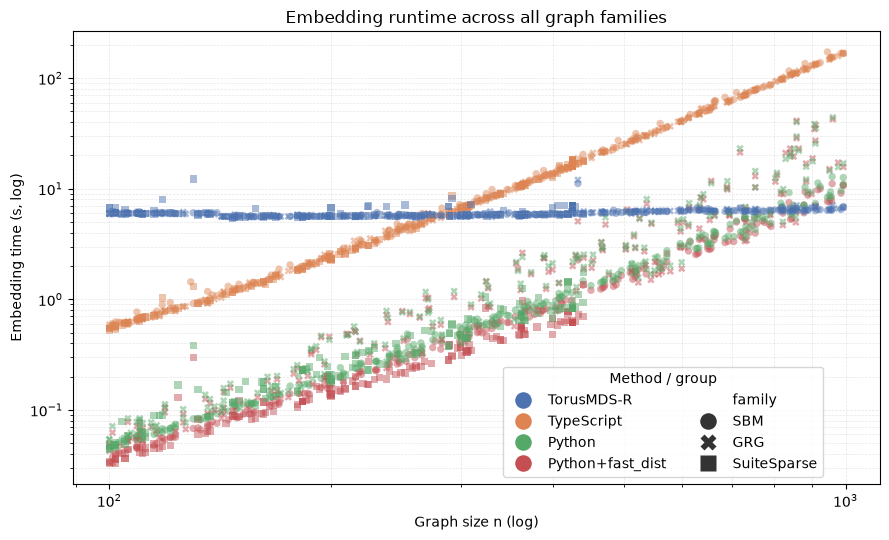

In [82]:
def plot_runtime_scatter(family=None, facet=None, save=True):
    """Plot runtime vs n for one family or every family; colour = method, marker = family/facet."""
    plot_data = datasets.loc[datasets.method.isin(METHODS)].copy()
    if family is not None:
        plot_data = plot_data.loc[plot_data.family.eq(family)]
    style = facet if facet is not None else ('family' if family is None else None)

    scatter_kwargs = dict(
        data=plot_data, x='n', y='t_embed', hue='method', style=style,
        hue_order=METHODS, palette=COLORS, s=28, alpha=0.48,
        edgecolor='none',
    )
    if style == 'family':
        scatter_kwargs['markers'] = FAMILY_MARKERS

    fig, ax = plt.subplots(figsize=(9, 5.5))
    sns.scatterplot(**scatter_kwargs, ax=ax)
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel('Graph size n (log)')
    ax.set_ylabel('Embedding time (s, log)')
    title = 'Embedding runtime across all graph families' if family is None else f'{family}: embedding runtime'
    ax.set_title(title)
    ax.grid(which='both', linestyle='--', alpha=0.32)

    if False:
        handles, labels = ax.get_legend_handles_labels()
        labels = [METHOD_LABELS.get(label, label) for label in labels]
    else:
        handles, labels = ax.get_legend_handles_labels()
        legend_entries = [
            (handle, METHOD_LABELS.get(label, label))
            for handle, label in zip(handles, labels)
            if label not in {'method', 'graph_class'}
        ]
        for handle, label in legend_entries:
            handle.set_markersize(handle.get_markersize() * 1.25)
            handle.set_alpha(1)
        handles, labels = zip(*legend_entries)
    ax.legend(handles, labels, title='Method / group' if style else 'Method',
              bbox_to_anchor=(0.525, 0.0), loc='lower left', ncols=2)
    fig.tight_layout()
    if save:
        name = 'all_wraps_runtime_scatter.png' if family is None else f'{family.lower()}_wraps_runtime_scatter.png'
        fig.savefig(RESULTS_DIR / name, dpi=160, bbox_inches='tight')
    return fig, ax

fig, ax = plot_runtime_scatter()
plt.show()

## Half-violin + strip plots: distribution shape and raw points together

Per-instance stress SPC against `TorusMDS`; the dashed zero line is the TorusMDS baseline. Positive values indicate higher (worse) stress.

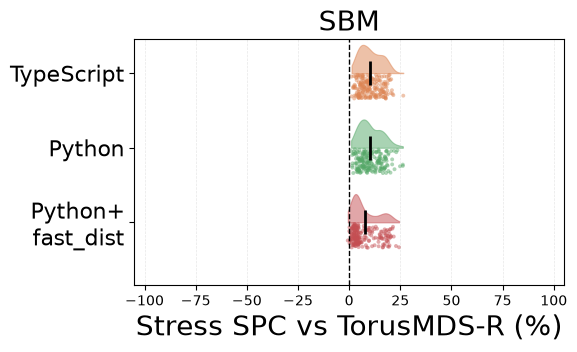

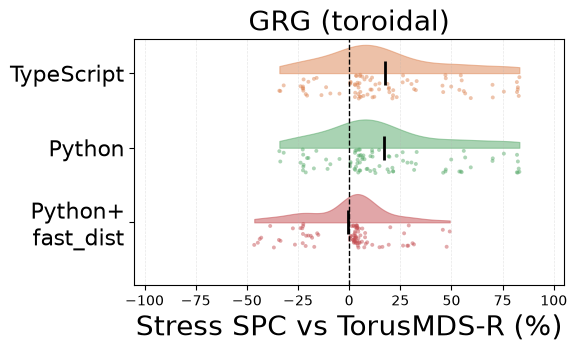

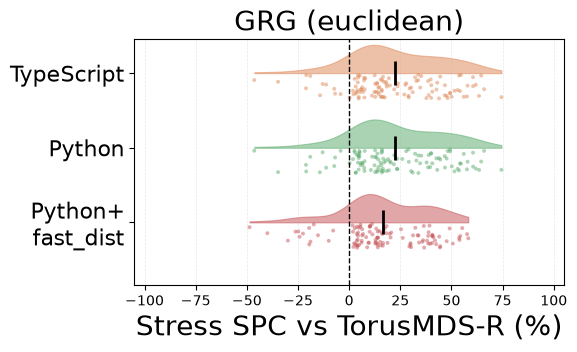

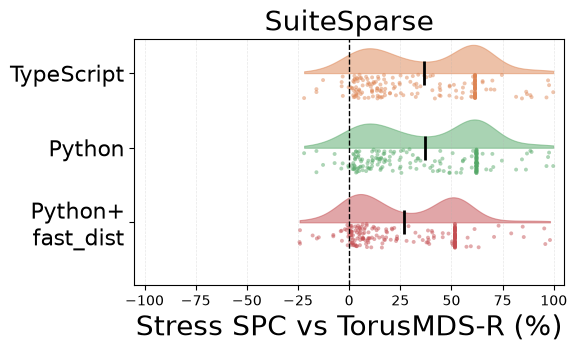

In [84]:
from scipy.stats import gaussian_kde

latex_width = 424
fraction = 1.0
fig_width_pt = latex_width * fraction
# Convert from pt to inches
inches_per_pt = 1 / 72.27
golden_ratio = (5**.5 - 1) / 2

# Figure width in inches
fig_width_in = fig_width_pt * inches_per_pt
# Figure height in inches
fig_height_in = fig_width_in * golden_ratio


SPC_GROUPS = [
    ('SBM', datasets.family.eq('SBM')),
    ('GRG (toroidal)', datasets.family.eq('GRG') & datasets.graph_type.eq('toroidal')),
    ('GRG (euclidean)', datasets.family.eq('GRG') & datasets.graph_type.eq('euclidean')),
    ('SuiteSparse', datasets.family.eq('SuiteSparse')),
]
SPC_METHODS = [method for method in METHODS if method != 'TorusMDS_random_1x_scale2']

def per_instance_stress_spc(frame, method, baseline='TorusMDS_random_1x_scale2'):
    """Graph-wise stress SPC; invalid/mismatched synthetic pairs are omitted."""
    pairs = paired_metric_values(frame, method, baseline, metric='stress')
    denominator = np.maximum(np.abs(pairs.method_value), np.abs(pairs.baseline_value))
    pairs = pairs.loc[denominator.gt(0)].copy()
    pairs['spc'] = 100 * (pairs.method_value - pairs.baseline_value) / denominator.loc[pairs.index]
    pairs['method'] = method
    return pairs[['exp_idx', 'method', 'spc']]

def half_violin_strip(ax, sub, methods, violin_height=0.38, strip_height=0.34, seed=0):
    """Half-violin KDE below each method row; raw SPC points above it; tick = mean."""
    rng = np.random.default_rng(seed)
    for yi, method in enumerate(methods):
        values = sub.loc[sub.method.eq(method), 'spc'].dropna().to_numpy()
        if len(values) == 0:
            continue
        if len(values) >= 2 and np.ptp(values) > 0:
            xs = np.linspace(values.min(), values.max(), 200)
            density = gaussian_kde(values)(xs)
            density = density / density.max() * violin_height
            ax.fill_between(xs, yi, yi - density, color=COLORS[method], alpha=0.5, linewidth=0.8)
        jitter = yi + rng.uniform(0.02, strip_height, size=len(values))
        ax.scatter(values, jitter, s=8, alpha=0.48, color=COLORS[method], edgecolors='none')
        ax.scatter(values.mean(), yi, marker='|', s=300, linewidths=2, color='black', zorder=5)

for group_label, mask in SPC_GROUPS:
    frame = datasets.loc[mask]
    spc_long = pd.concat([per_instance_stress_spc(frame, method) for method in SPC_METHODS], ignore_index=True)
    present_methods = [method for method in SPC_METHODS if spc_long.method.eq(method).sum() >= 5]
    y_labels = [
        'Python+\nfast_dist' if METHOD_LABELS[method] == 'Python+fast_dist' else METHOD_LABELS[method]
        for method in present_methods
    ]

    fig, ax = plt.subplots(figsize=(fig_width_in, fig_height_in))
    half_violin_strip(ax, spc_long, present_methods)
    ax.axvline(0, color='black', linestyle='--', linewidth=1, label='TorusMDS-R baseline')
    ax.set_xlim(-105, 105)
    ax.set_yticks(range(len(present_methods)), y_labels, fontsize=16)
    ax.set_ylim(len(present_methods) - 0.16, -0.46)
    ax.set_xlabel('Stress SPC vs TorusMDS-R (%)', fontsize=20)
    ax.set_title(group_label, fontsize=20)
    ax.grid(axis='x', linestyle='--', alpha=0.3)
    # ax.legend(loc='upper left', fontsize=8)
    fig.tight_layout()
    filename = group_label.lower().replace(' ', '_').replace('(', '').replace(')', '')
    fig.savefig(RESULTS_DIR / f'half_violin_stress_spc_{filename}.png', dpi=160, bbox_inches='tight')
    plt.show()
